In [95]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('intakes.csv')

Intake Type
Stray                 86455
Owner Surrender       24606
Public Assist          7621
Wildlife               4898
Abandoned               283
Euthanasia Request      257
Name: count, dtype: int64


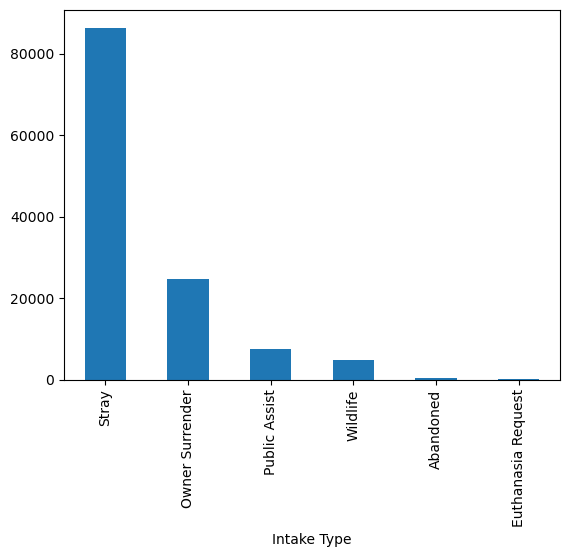

In [96]:
print(df["Intake Type"].value_counts())
df["Intake Type"].value_counts().plot(kind="bar")
plt.show()

--- Tabulka stavu zvířat při příjmu ---
Intake Condition  Aged  Behavior  Feral  Injured  Medical  Normal  Nursing  \
Animal Type                                                                  
Bird                 0         0      0      165        0     405        0   
Cat                 53         1     98     2656       20   39278     2255   
Dog                374        19      9     2974       43   64004     1175   
Livestock            0         0      0        0        0      21        0   
Other                3         0      1      844        0    4244       94   

Intake Condition  Other  Pregnant  Sick  
Animal Type                              
Bird                  7         0     9  
Cat                  90        22  1982  
Dog                 127        55  1667  
Livestock             0         0     1  
Other                 5         0  1419  


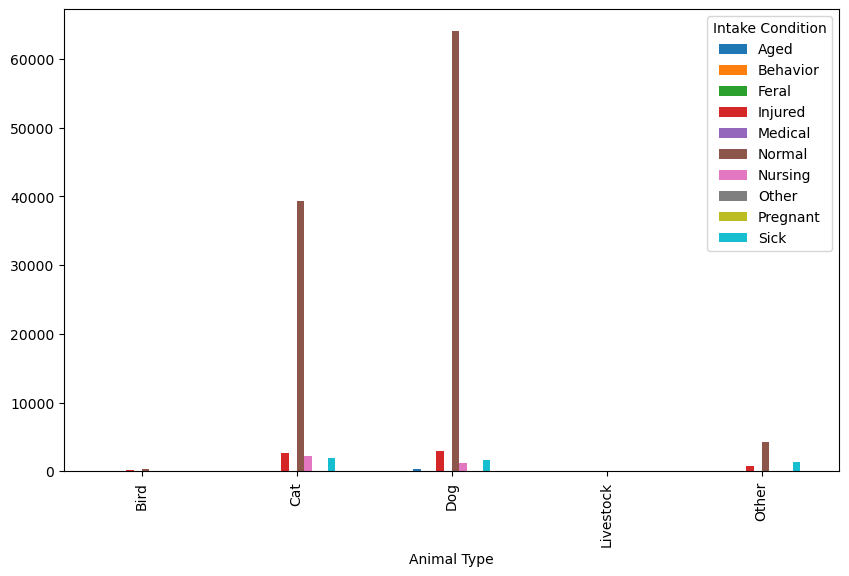

In [97]:
tabulka = pd.crosstab(df["Animal Type"], df["Intake Condition"])

print("--- Tabulka stavu zvířat při příjmu ---")
print(tabulka)

ax = tabulka.plot(kind="bar", figsize=(10, 6))

Intake Condition  Aged  Behavior  Feral  Injured  Medical  Normal  Nursing  \
Animal Type                                                                  
Cat                 53         1     98     2656       20   39278     2255   
Dog                374        19      9     2974       43   64004     1175   

Intake Condition  Other  Pregnant  Sick  
Animal Type                              
Cat                  90        22  1982  
Dog                 127        55  1667  


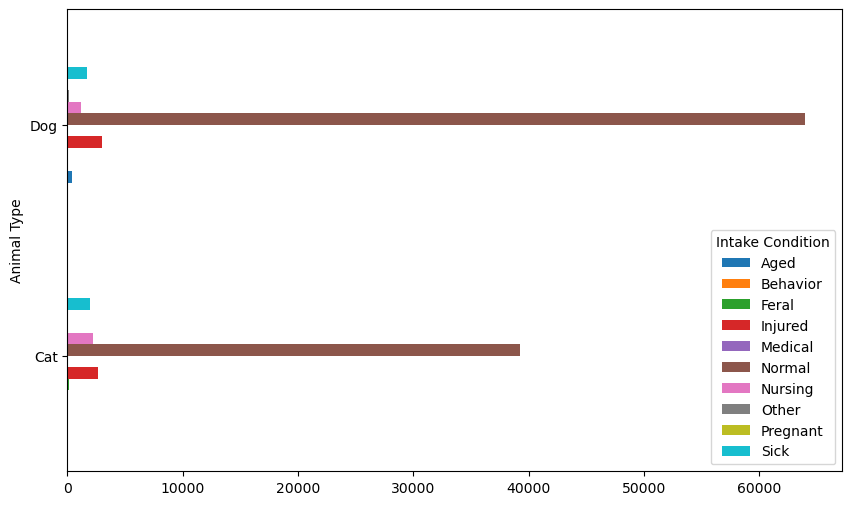

In [98]:
#jenom kočky a psi
df_filtered = df[df["Animal Type"].isin(["Dog", "Cat"])]
tabulka = pd.crosstab(df_filtered["Animal Type"], df_filtered["Intake Condition"])

print(tabulka)

ax = tabulka.plot(kind="barh", figsize=(10, 6), cmap="tab10")

Breed
Pig             15
Goat             3
Potbelly Pig     2
Sheep            1
Pygmy            1
Name: count, dtype: int64


Text(0, 0.5, '')

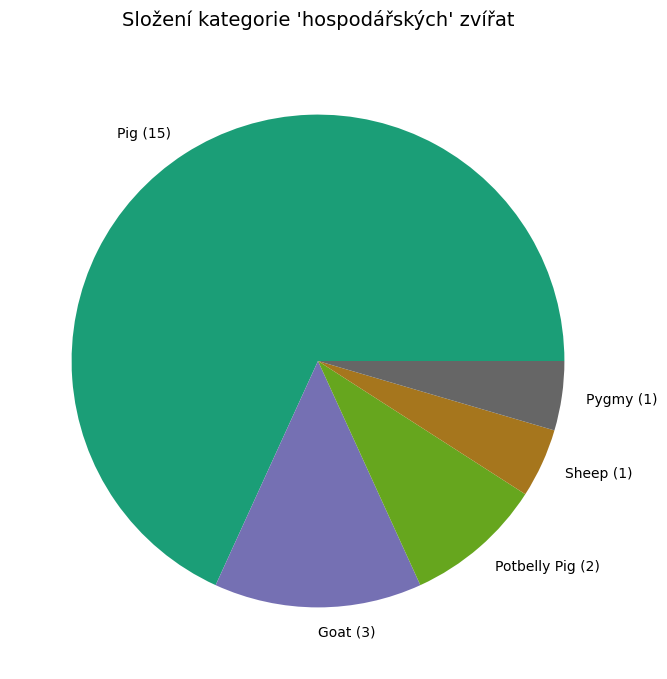

In [99]:
df_livestock = (df[df['Animal Type'] == 'Livestock'])
breeds = df_livestock['Breed'].str.replace(" Mix", "", case = False) #vyčištění duplikátů typu Pig a Pig Mix
species_counts = breeds.value_counts()
print(species_counts)

popisky_s_cisly = [f"{nazev} ({pocet})" for nazev, pocet in species_counts.items()]
plt.figure(figsize = (8,8))
species_counts.plot(
    kind = 'pie',
    labels = popisky_s_cisly,
    cmap = 'Dark2'
)
plt.title("Složení kategorie 'hospodářských' zvířat", fontsize=14, pad=20)
plt.ylabel("")

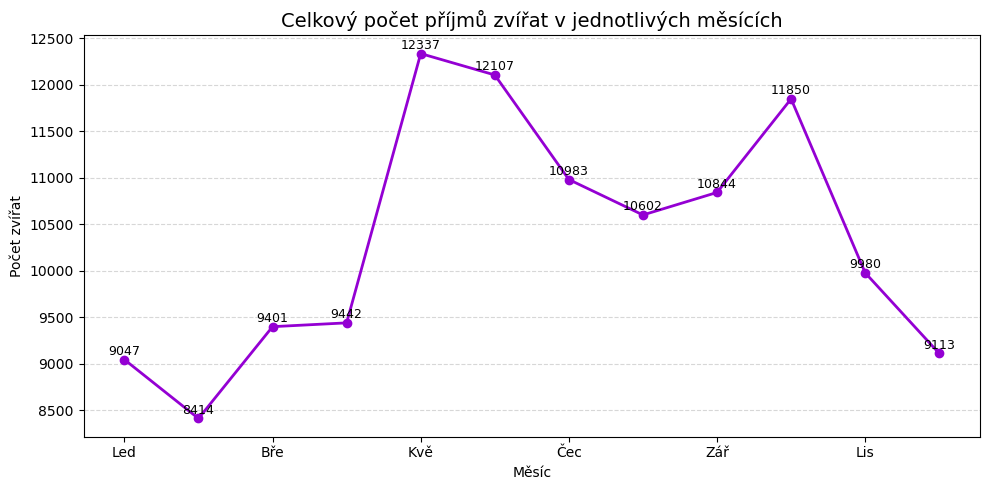

In [100]:
df["DateTime"] = pd.to_datetime(df["DateTime"], format="%m/%d/%Y %I:%M:%S %p")

#vytvoření nového sloupce, kde bude jen číslo měsíce
df["Month"] = df["DateTime"].dt.month

# kolik zvířat přišlo v jednotlivých měsících
monthly_counts = df["Month"].value_counts().sort_index()

mesice = [
    "Led",
    "Úno",
    "Bře",
    "Dub",
    "Kvě",
    "Čer",
    "Čec",
    "Srp",
    "Zář",
    "Říj",
    "Lis",
    "Pro",
]
monthly_counts.index = mesice

plt.figure(figsize=(10, 5))
monthly_counts.plot(kind="line", marker="o", color="DarkViolet", linewidth=2)

for i, v in enumerate(monthly_counts):
    plt.text(i, v + 50, str(v), ha="center", fontsize=9)

plt.title("Celkový počet příjmů zvířat v jednotlivých měsících", fontsize=14)
plt.xlabel("Měsíc")
plt.ylabel("Počet zvířat")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()